# UNO Vision Challenge — Classical Pipeline

**Group 44**: Turcanu Magdalena (416457), Jakub Jan Kielar (423372), Zwygart Hanna (333423)

Given a snapshot of an UNO game, we recover the full game state:
* the **center card** on the table,
* the **active player** (whose turn it is),
* the **set of cards** held by each of the four players.

We use a classical image-processing pipeline composed of three stages, each isolated in its own module under `src/`:

| Stage | Module | Purpose |
|---|---|---|
| Segmentation | `src/segmentation.py` | Per-color HSV thresholding + morphology → one rotated crop per card / token |
| Object description | `src/description.py` | Dominant card colour + binary symbol signature inside the white oval |
| Classification | `src/classification.py` | Template database built from the 4 reference images, matched by NCC |
| Game-state inference | `src/game_state.py` | Player assignment from angle, center detection, active player from token |

The pipeline obeys all challenge rules: no external datasets, no pretrained models, no learning models at all. Only the four reference images and the provided training annotations were inspected during development.

In [1]:
import os, sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image
import warnings; warnings.filterwarnings('ignore')

from src.segmentation import detect_cards, detect_tokens, hsv_card_mask
from src.description import card_color, symbol_signature, best_match_score
from src.classification import build_templates, classify_card
from src.game_state import assign_game_state
from src.pipeline import predict_image

TRAIN_DIR = 'train_images'
REF_DIR = 'reference_images'
train = pd.read_csv('train.csv').set_index('image_id')
print(f'{len(train)} labeled training images')

81 labeled training images


## 1. Segmentation

Each UNO card is dominated by one of five colour profiles in HSV space — red, yellow, green, blue, or near-black for wild / draw_4. The cards rest on either a near-white tabletop or a noisy leaf-pattern fabric. A per-channel threshold tuned on representative training images (white background `L1000770` and noisy background `L1000902`) reliably separates colored cards from both backgrounds. The same dark-mask catches wild cards and the active-player token.

After thresholding, light morphology cleans the binary mask:
* `remove_small_objects(min_size=60)` kills isolated pixels.
* `binary_closing(disk(9))` fills small gaps along each colored ring.
* `remove_small_objects(min_size=4000)` removes leaf fragments and other noise.

We deliberately do **not** fill the holes inside the colored rings here — those holes (the white ovals printed on every numbered card) are reused later as one-per-card anchors for stacked-hand detection.

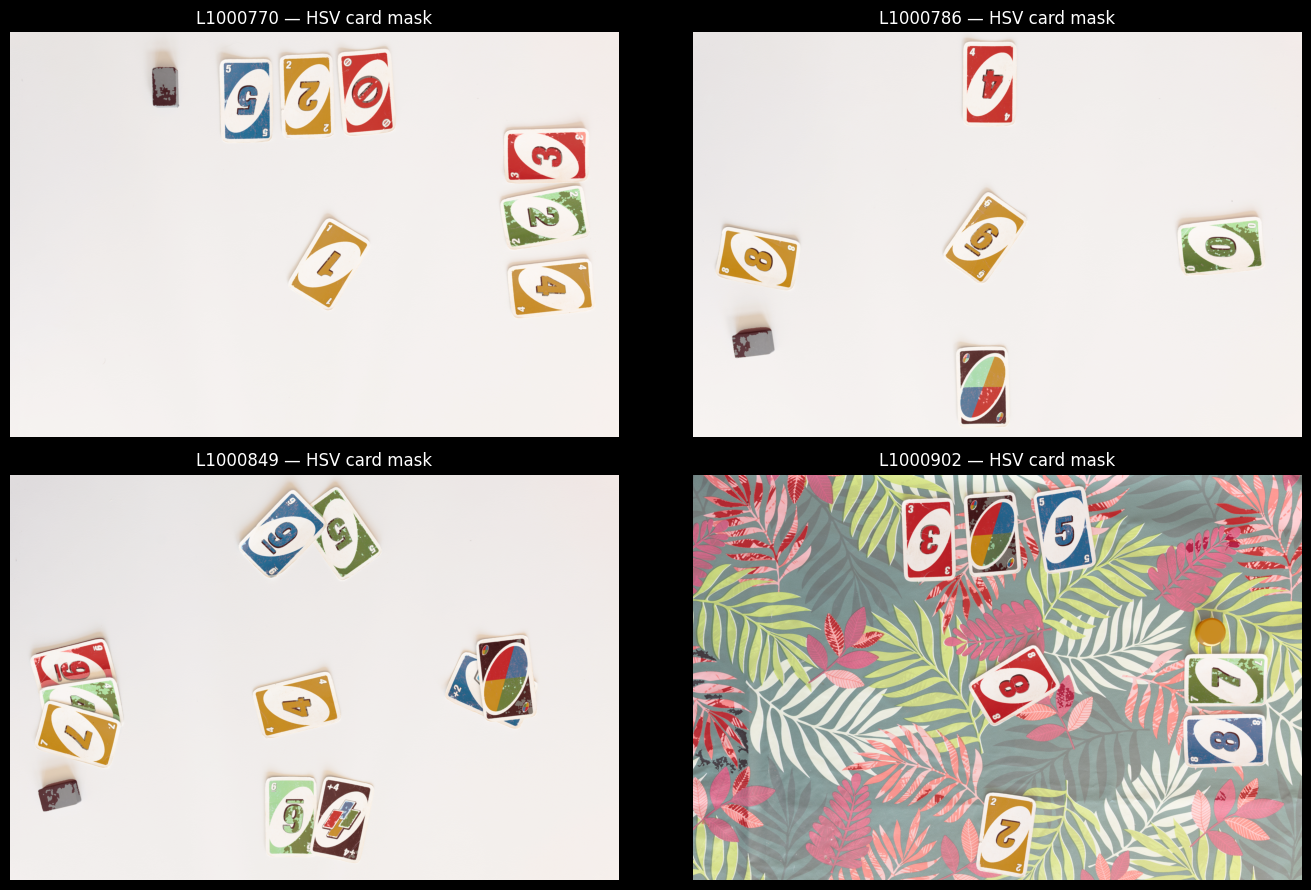

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, name in zip(axes.flatten(), ['L1000770', 'L1000786', 'L1000849', 'L1000902']):
    img = np.array(Image.open(f'{TRAIN_DIR}/{name}.jpg'))
    mask = hsv_card_mask(img)
    ax.imshow(img); ax.imshow(mask, alpha=0.35, cmap='Reds'); ax.axis('off')
    ax.set_title(f'{name} — HSV card mask')
plt.tight_layout(); plt.show()

### From mask to per-card crops

Each card's colored ring fragments into several connected components after thresholding (e.g. the colored border and the inner colored digit are separated by the white oval). To recover one entity per card we **single-linkage cluster** the fragment centroids with a tolerance of 200 px, which is the typical card diagonal: pieces that close together belong to the same card.

For each cluster we take the union of its fragment masks, fit a rotated bounding rectangle (`cv2.minAreaRect`), and reject anything outside a sensible card shape (aspect ratio 1.1–2.2, total area ≥ 16 k px). A perspective warp produces a 160×240 canonical crop. When the total cluster area is far larger than a single card (≥ 1.5×), we treat the cluster as a possibly stacked hand and look for **multiple white ovals inside it** — one oval = one card; we emit one crop per oval. Wild / draw_4 cards have no white oval, so they always come out as single-card clusters from the dark mask.

L1000771: detected 7 cards


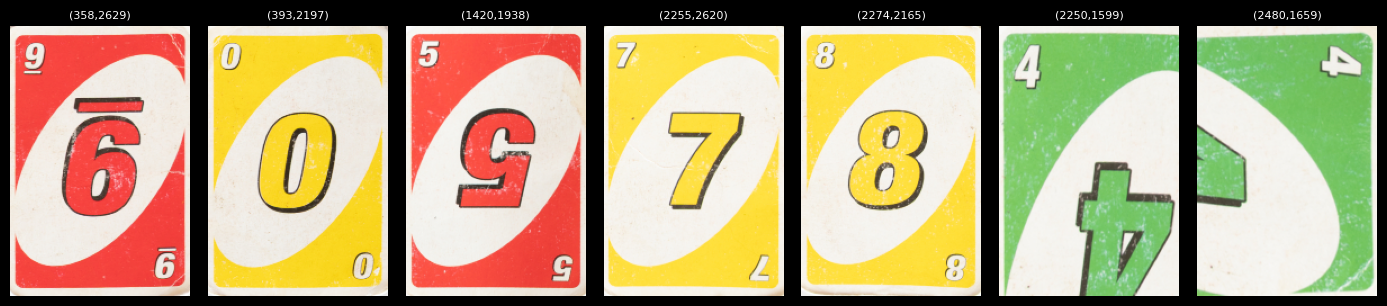

In [3]:
name = 'L1000771'
img = np.array(Image.open(f'{TRAIN_DIR}/{name}.jpg'))
cards = detect_cards(img)
print(f'{name}: detected {len(cards)} cards')
fig, axes = plt.subplots(1, len(cards), figsize=(2*len(cards), 3))
if len(cards) == 1: axes = [axes]
for ax, c in zip(axes, cards):
    ax.imshow(c['crop']); ax.axis('off')
    ax.set_title(f"({int(c['centroid'][0])},{int(c['centroid'][1])})", fontsize=8)
plt.tight_layout(); plt.show()

## 2. Object Description

Each card crop is reduced to two compact descriptors:

* **Dominant colour** (`card_color`): mean HSV is taken over the inner 70% of the crop (the card body, ignoring background bleed). We first check for the dark-card signature (low value, low saturation — the wild / draw_4 black background), then fall back to scoring four hue bands and picking the largest.
* **Symbol signature** (`symbol_signature`): the central white oval is cropped (inner 60% × 56%), binarised by `S > 0.30 OR V < 0.40` (the digit/icon is either saturated colour or near-black outline on white), and resized to 96×96. This isolates the *shape* of the digit / action icon and discards lighting and color cast.

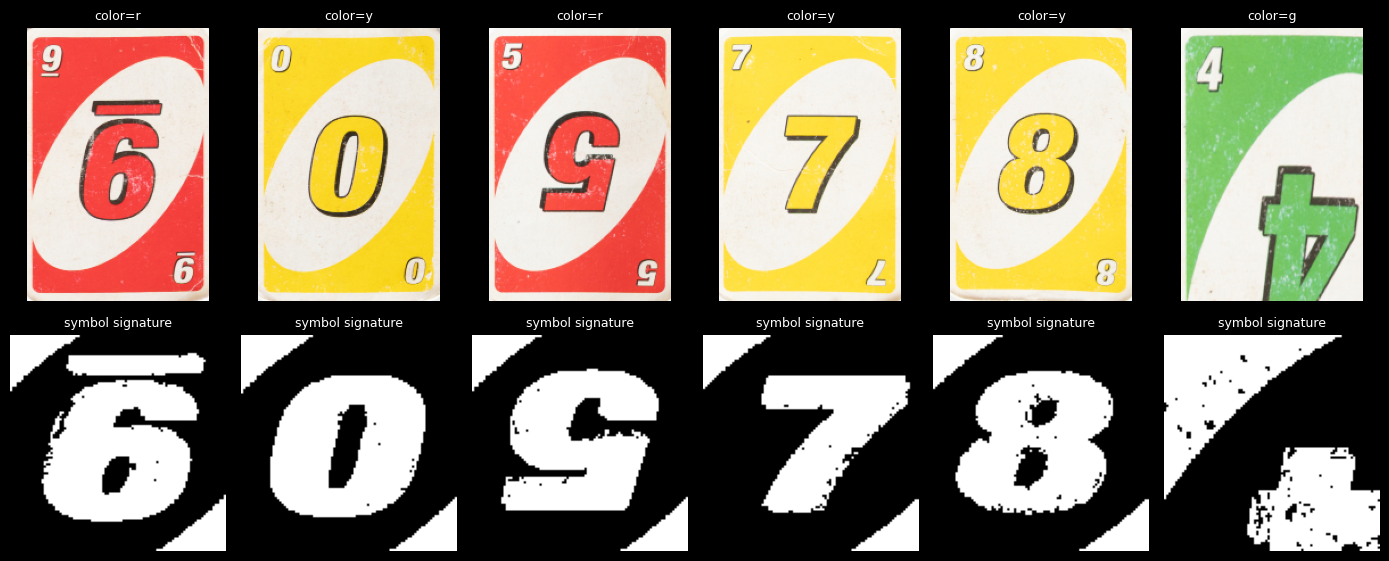

In [4]:
fig, axes = plt.subplots(2, 6, figsize=(14, 6))
for i, c in enumerate(cards[:6]):
    sig = symbol_signature(c['crop'])
    axes[0, i].imshow(c['crop']); axes[0, i].axis('off')
    axes[0, i].set_title(f'color={card_color(c["crop"])}', fontsize=9)
    axes[1, i].imshow(sig, cmap='gray'); axes[1, i].axis('off')
    axes[1, i].set_title('symbol signature', fontsize=9)
plt.tight_layout(); plt.show()

## 3. Classification (reference templates + NCC)

The classifier is a template library built once from the four reference images, which together show every UNO card type exactly once. `build_templates`:
1. Runs the same segmentation pipeline on each reference image,
2. Sorts the detected cards by image position into the known grid layout,
3. Stores `(label, color_key, symbol_signature)` for the 54 card classes (4 colors × 13 values + wild + draw_4).

At test time `classify_card` restricts candidates to the predicted color, then scores each by **normalised cross-correlation** of the binary symbol signatures, trying both upright and 180°-rotated orientations of the template. Two confidence filters reject phantoms:
* A general threshold `NCC ≥ 0.50` for all classes — most truly cropped cards score above 0.85;
* A stricter threshold `NCC ≥ 0.55` for `k`-colour (wild / draw_4) — shadows and stray dark blobs rarely match a real wild template.

In [5]:
templates = build_templates(REF_DIR)
print(f'Template DB: {len(templates)} cards')
for c in cards:
    label, color, score = classify_card(c['crop'], templates)
    print(f"  centroid={tuple(int(x) for x in c['centroid'])} -> {label} (color={color}, ncc={score:.3f})")

Template DB: 54 cards
  centroid=(358, 2629) -> r_9 (color=r, ncc=0.963)
  centroid=(393, 2197) -> y_0 (color=y, ncc=0.945)
  centroid=(1420, 1938) -> r_5 (color=r, ncc=0.931)
  centroid=(2255, 2620) -> y_1 (color=y, ncc=0.663)
  centroid=(2274, 2165) -> y_8 (color=y, ncc=0.946)
  centroid=(2250, 1599) -> g_1 (color=g, ncc=0.503)
  centroid=(2480, 1659) -> None (color=g, ncc=0.035)


## 4. Game-State Inference

Once we have a set of accepted cards and detected token blobs, `assign_game_state` reconstructs the table layout:

* **Center card**: the card with the smallest distance to the image centre, but only if that distance is below 35% of the image diagonal (otherwise no center card).
* **Player assignment**: each remaining card is assigned to a player by the angle of its centroid from the image centre, with the four quadrants mapping to `p1` (bottom), `p2` (right), `p3` (top), `p4` (left).
* **Active player**: token candidates are detected in a second pass (small dark or yellow blob, area 500–4500 px, aspect < 1.7, contour fill ratio > 0.65) **outside the already-classified card regions** — this prevents a wild card from masquerading as a token. We then pick the candidate closest to any player's hand and report that player as active.

In [6]:
pred = predict_image(img, templates)
truth = train.loc[name].to_dict()
for k in pred:
    mark = '✓' if pred[k] == truth.get(k, '') else '✗'
    print(f'  {k:18}  pred={pred[k]:<35} truth={truth.get(k,"?")}  {mark}')

  center_card         pred=r_5                                 truth=r_5  ✓
  active_player       pred=p1                                  truth=p1  ✓
  player_1_cards      pred=y_1;y_8;g_1                         truth=y_7;y_8;g_4  ✗
  player_2_cards      pred=EMPTY                               truth=EMPTY  ✓
  player_3_cards      pred=r_9;y_0                             truth=r_9;y_0  ✓
  player_4_cards      pred=EMPTY                               truth=EMPTY  ✓


## 5. Evaluation on the training set

We evaluate the full pipeline on the 81 annotated training images. We track four metrics:
* `center_card` exact-match accuracy
* `active_player` exact-match accuracy
* hand exact-match: a player's hand is correct iff the predicted card multiset equals the truth multiset
* card-level micro-precision / recall / F1 across all four hands

On this run the pipeline reaches **center ≈ 91 %**, **active player ≈ 43 %**, **card F1 ≈ 0.67** with very high precision (~0.99) — the rejection threshold keeps phantom cards out at the cost of missing some real cards in heavily stacked hands.

In [7]:
# To reproduce the headline numbers, run `python scripts/eval_train.py` from
# the project root. The cell below evaluates the first 10 images so the
# notebook runs quickly.
from scripts.eval_train import main as eval_main
_ = eval_main(limit=10)

  10/10 (27.7s)

N=10
center_card acc: 10/10 = 100.0%
active_player acc: 2/10 = 20.0%
hand exact-match: 24/40 = 60.0%
card-level precision=0.899, recall=0.785, f1=0.838


## 6. Producing the Kaggle submission

Running `python main.py --test_dir test_images --ref_dir reference_images --out submission.csv` from the project root reproduces the submission file uploaded to Kaggle. Every image_id in `test_images/` appears in the output; players with no detected cards are emitted as `EMPTY`.